# Load a TIB-AV-A Project File

In [1]:
import io

colab = False
try:
    from google.colab import files
    colab = True
    uploaded = files.upload()
    zip_buffer = io.BytesIO(list(uploaded.values())[0])
except ImportError:
    import ipywidgets as widgets
    from IPython.display import display
    
    upload = widgets.FileUpload(multiple=False)

    display(upload)


FileUpload(value=(), description='Upload')

In [2]:
if not colab:
    uploaded_file = upload.value[0]
    content = uploaded_file['content']
    zip_buffer = io.BytesIO(content)
else:
    !pip install tibava-data av imageio msgpack valkey

# Take a Look at the File 

In [3]:
import zipfile
import yaml
import json
import data as tibava_data

data_manager = tibava_data.DataManager()

with zipfile.ZipFile(zip_buffer, "r") as zip_file:
    for name in zip_file.namelist():
        if name.startswith("data/") and name.endswith(".zip"):
            with zip_file.open(name) as f:
                with data_manager.load_from_io(f) as data:
                    print(data.type, data.id)
                

ShotsData 741509e92cf040b78efef7aed55b5f70
ImagesData d02d96e22fb34d48ab58a23019572e1e
ScalarData 317e03c895014cd4948c89c3f4b4fc5b
ScalarData 7fc2e2dbe6674c799bd08a3d0eef1574
ScalarData c4fbe0e23fd147948c0d37557784cb9a
ScalarData 80e081a5b98a4c34ba5f591f8c78c32d
ScalarData fbcd766c256047228f256eceb443fa74
ScalarData 34d6cf3e32924994b3101586c240a5f4
ScalarData 4c22eaff31cd4419b976d7e221956aac
ClusterData 7d80aae9a72f406b809caf19c376e7bf
FacesData 8d3648c99950422bb2d19565183cf0df
BboxesData 0af1b534beb84b94bf943bd3ed5eee38
KpssData cf6c78dc78ce41e7b4841e9cf74a9766
ImagesData 5b1004a1bfc0424eb77afba7eb3f2641
ImageEmbeddings eece078e4cca4a01ba0064f634c7f5cf
ScalarData c482ebc239c54a839e2a1d5fc824f533
ScalarData e42e46d9bdaf4e28942c54c8d43e629b
ScalarData 048054d5d780481095bda34c57308133
ScalarData b9004043ea1d49ac9a9cdf2544f2b22b
ScalarData d2896d0405b4416fb73b12f8448696a5
ScalarData e943c5e81e16486dbc9ba6294d00a4a6
AnnotationData 821238fa4d1e4c2aa802ee0174639e76
AnnotationData 4e439cb2611

# Read Shot Size Information

In [4]:
shot_annotations = []
shot_start_end = []

def data_iterator(zip_buffer):
    with zipfile.ZipFile(zip_buffer, "r") as zip_file:
        for name in zip_file.namelist():
            if name.startswith("data/") and name.endswith(".zip"):
                with zip_file.open(name) as f:
                    with data_manager.load_from_io(f) as data:
                        yield data

for data in data_iterator(zip_buffer):
    
    shot_annotations = []
    shot_start_end = []
    #if data.type == "FacesData":
    #    print(data)
    if data.type == "AnnotationData":
        for x in data.annotations:
            for label in x.labels:
                if "Shot Size::" in label:
                    shot_annotations.append(label.split("Shot Size::")[-1])
                    shot_start_end.append([x.start, x.end])

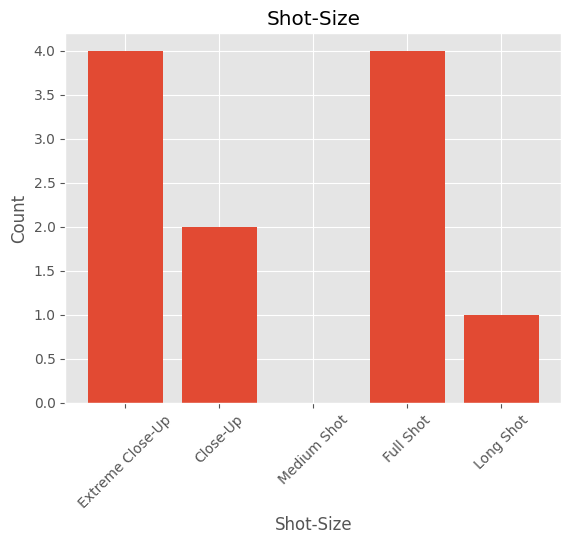

In [5]:
import matplotlib.pyplot as plt
# plt.style.use("seaborn-v0_8-whitegrid")
plt.style.use("ggplot")

labels = ["Extreme Close-Up", "Close-Up", "Medium Shot", "Full Shot", "Long Shot"]
values = [0 for x in labels]

for x in shot_annotations:
    label_index = labels.index(x)
    values[label_index]+=1     
    
plt.bar(labels, values)
plt.xlabel("Shot-Size")
plt.ylabel("Count")
plt.title("Shot-Size")
plt.xticks(rotation=45)
plt.show()

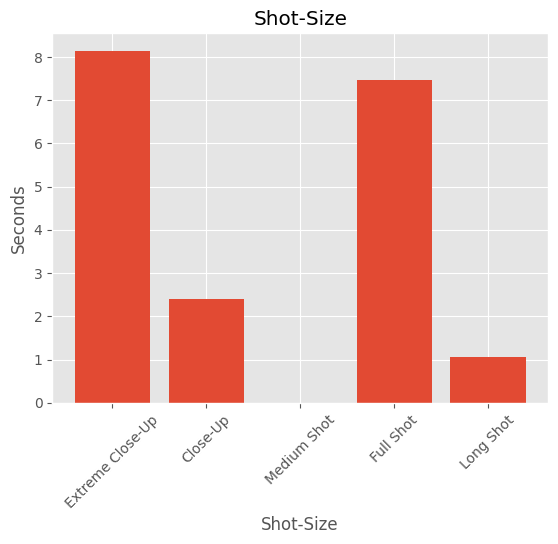

In [6]:
import matplotlib.pyplot as plt

labels = ["Extreme Close-Up", "Close-Up", "Medium Shot", "Full Shot", "Long Shot"]
values = [0.0 for x in labels]

for x in shot_annotations:
    label_index = labels.index(x)
    values[label_index]+=shot_start_end[label_index][1] - shot_start_end[label_index][0]   
    
plt.bar(labels, values)
plt.xlabel("Shot-Size")
plt.ylabel("Seconds")
plt.title("Shot-Size")
plt.xticks(rotation=45)
plt.show()

# Read Face Clustering Data Information

In [7]:
faces = {}
for data in data_iterator(zip_buffer):
    if data.type == "FacesData":
        for face in data.faces:
            faces[face.id]={}
            
embeddings_map = {}
for data in data_iterator(zip_buffer):
    if data.type == "ImageEmbeddings":
        for emb in data.embeddings:
            embeddings_map[emb.id] = emb.ref_id
            faces[emb.ref_id]["time"] = emb.time
    if data.type == "BboxesData":
        for bbox in data.bboxes:
            faces[bbox.ref_id]["bbox"] = bbox.to_dict()

for data in data_iterator(zip_buffer):
    if data.type == "ClusterData":
        for i, cluster in enumerate(data.clusters):
            for id in cluster.embedding_ids:
                faces[embeddings_map[id]]["cluster"] = i

print(list(faces.items())[0])


('7465b99295e24867ad5458831c069bd5', {'bbox': {'id': '4940ca24c51b44e6928db4f70cb5eddc', 'version': '1.0', 'type': 'PluginData', 'name': None, 'ref_id': '7465b99295e24867ad5458831c069bd5', 'x': 0.44427083333333334, 'y': 0.2074074074074074, 'w': 0.10625, 'h': 0.2962962962962963, 'det_score': 0.81494140625, 'time': 2.5, 'delta_time': 0.5, 'image_id': None}, 'time': 2.5, 'cluster': 3})


In [8]:
# init the result entry
shot_face_count = {
    "Extreme Close-Up":[0,0,0], 
    "Close-Up":[0,0,0], 
    "Medium Shot":[0,0,0], 
    "Full Shot":[0,0,0], 
    "Long Shot":[0,0,0]
}

for index, [shot_start, shot_end] in enumerate(shot_start_end):
    shot_faces = set()
    for face in faces.values():
        if shot_start<face["time"] and face["time"] < shot_end:
            shot_faces.add(face["cluster"])
    
    anno = shot_annotations[index]

    # distinction based on the number of faces
    if len(shot_faces) == 1:
        shot_face_count[anno][0] +=1
    if len(shot_faces) == 2:
        shot_face_count[anno][1] +=1
    if len(shot_faces) > 2:
        shot_face_count[anno][2] +=1
    
        

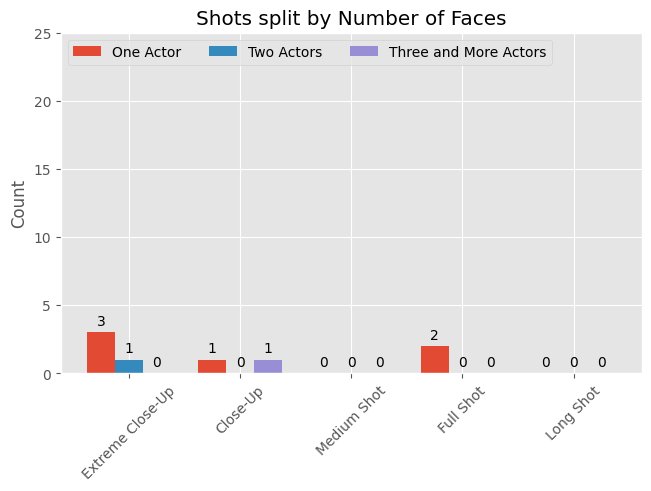

In [9]:
import numpy as np

x = np.arange(len(shot_face_count))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for num_faces, label in enumerate(["One Actor", "Two Actors", "Three and More Actors"]):
    offset = width * multiplier
    rects = ax.bar(x + offset, [x[num_faces] for x in shot_face_count.values()], width, label=label)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count')
ax.set_title('Shots split by Number of Faces')
ax.set_xticks(x + width, shot_face_count.keys())
ax.legend(loc='upper left', ncols=3)

plt.xticks(rotation=45)
ax.set_ylim(0, 25)

plt.show()

# Shot Reverse Shot Detection

In [10]:

shot_face_list = []

for index, [shot_start, shot_end] in enumerate(shot_start_end):
    shot_faces = set()
    for face in faces.values():
        if shot_start<face["time"] and face["time"] < shot_end:
            shot_faces.add(face["cluster"])

    shot_face_list.append(list(shot_faces))

def detect_shot_reverse_shot(shots, min_length=4):
    results = []
    n = len(shots)
    i = 0

    while i < n - 2:

        # Check first two shots are single-person and different
        if len(shots[i]) == 1 and len(shots[i+1]) == 1:
            A = shots[i][0]
            B = shots[i+1][0]

            if A != B:

                start = i
                expected = A
                j = i

                # Follow alternating pattern
                while j < n and len(shots[j]) == 1:
                    current = shots[j][0]

                    if current != expected:
                        break

                    # Switch expected speaker
                    expected = B if expected == A else A
                    j += 1

                length = j - start

                if length >= min_length:
                    results.append((start, j-1, (A, B)))
                    i = j  # skip past this block
                    continue

        i += 1

    return results
    
# get all shot_reverse_shot results
srs_list = detect_shot_reverse_shot(shot_face_list)


In [11]:
time_image_list = []

for data in data_iterator(zip_buffer):
    if data.type == "ImagesData":
        for image in data.images:
            # skip face images
            if image.ref_id is not None:
                continue
                
            img = data.load_image(image)
            time_image_list.append([image.time, img])

# show these shots

def show_shot_sequences(shot_list,time_image_list):

    def show_images(images):
        n = len(images)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    
        if n == 1:
            axes = [axes]
    
        for ax, img in zip(axes, images):
            ax.imshow(img)
            ax.axis("off")
    
        plt.tight_layout()
        plt.show()
        
    for shot in shot_list:
        images_list = []
        for shot_index in range(shot[0], shot[1]):
            start = shot_start_end[shot_index][0]
            end = shot_start_end[shot_index][1]
            for image in time_image_list:
                if start < image[0] and image[0] < end:
                    images_list.append(image[1])
                    break
    
        show_images(images_list)
show_shot_sequences(srs_list, time_image_list)

# Opposition

In [12]:
# Some helper functions
def iou_xywh(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Convert to (x1, y1, x2, y2)
    x1_max = x1 + w1
    y1_max = y1 + h1

    x2_max = x2 + w2
    y2_max = y2 + h2

    # Intersection rectangle
    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)

    # Compute intersection area
    inter_width = max(0, inter_x2 - inter_x1)
    inter_height = max(0, inter_y2 - inter_y1)
    inter_area = inter_width * inter_height

    # Areas of boxes
    area1 = w1 * h1
    area2 = w2 * h2

    # Union
    union_area = area1 + area2 - inter_area

    if union_area == 0:
        return 0

    return inter_area / union_area

def left_right_cls(bbox):
    l_iou = iou_xywh([bbox["x"], bbox["y"], bbox["w"], bbox["h"]],[0,0,0.5,1.0])
    r_iou = iou_xywh([bbox["x"], bbox["y"], bbox["w"], bbox["h"]],[0.5,0,0.5,1.0])
    return l_iou, r_iou


In [13]:

shot_face_left_right_list = []
for index, [shot_start, shot_end] in enumerate(shot_start_end):
    shot_faces = set()
    shot_left_right = {}
    for face in faces.values():
        if shot_start<face["time"] and face["time"] < shot_end:
            l_r = left_right_cls(face["bbox"])
            shot_faces.add(face["cluster"])
            
            if face["cluster"] not in shot_left_right:
                shot_left_right[face["cluster"]] = [0.0,0.0]
            shot_left_right[face["cluster"]][0]+= l_r[0]
            shot_left_right[face["cluster"]][1]+= l_r[1]

    shot_results = []
    for shot_face in shot_faces:
        shot_results.append({
            "cluster": shot_face,
            "lr":  "left" if shot_left_right[shot_face][0]>shot_left_right[shot_face][1] else "right"
        })
    
    shot_face_left_right_list.append(shot_results)


def detect_shot_reverse_shot_opposition(shots, min_length=4):
    results = []
    n = len(shots)
    i = 0

    while i < n - 2:

        # Check first two shots are single-person and different
        if len(shots[i]) == 1 and len(shots[i+1]) == 1:
            
            A = shots[i][0]["cluster"]
            B = shots[i+1][0]["cluster"]
            
            A_lr = shots[i][0]["lr"]
            B_lr = shots[i+1][0]["lr"]
            if A != B and A_lr != B_lr:

                start = i
                expected = A
                expected_lr = A_lr
                j = i

                # Follow alternating pattern
                while j < n and len(shots[j]) == 1:
                    current = shots[j][0]["cluster"]
                    current_lr = shots[j][0]["lr"]

                    if current != expected or current_lr != expected_lr:
                        break

                    # Switch expected speaker
                    expected = B if expected == A else A
                    expected_lr = B_lr if expected_lr == A_lr else A_lr
                    j += 1

                length = j - start

                if length >= min_length:
                    results.append((start, j-1, (A, B)))
                    i = j  # skip past this block
                    continue

        i += 1

    return results
    
# get all shot_reverse_shot results
srso_list = detect_shot_reverse_shot_opposition(shot_face_left_right_list)

In [14]:
show_shot_sequences(srso_list, time_image_list)

# Intensivierung

In [15]:
labels = ["Extreme Close-Up", "Close-Up", "Medium Shot", "Full Shot", "Long Shot"]

def detect_shot_intensification(shots, min_length=3):
    results = []
    n = len(shots)
    i = 0

    while i < n - 2:
        sequence = []
        A = labels.index(shots[i])
        B = labels.index(shots[i+1])
        # Check first two shots
          
        if A > B:
            print("##", shots[i], shots[i+1])
            start = i
            expected = labels.index(shots[i+1])
            j = i+2

            # Follow pattern
            while j < n:
                current = labels.index(shots[j])
                print("####", shots[j-1], shots[j], current > expected)

                sequence.append(current)
                
                if current > expected:
                    break

                expected =  labels.index(shots[j])
                j += 1

            length = j - start

            if length >= min_length:
                results.append((start, j-1, sequence))
                i = j  # skip past this block
                continue

        i += 1

    return results
    
# get all shot_reverse_shot results
intensification_list = detect_shot_intensification(shot_annotations)

## Full Shot Close-Up
#### Close-Up Extreme Close-Up False
#### Extreme Close-Up Full Shot True
## Full Shot Extreme Close-Up
#### Extreme Close-Up Close-Up True
## Full Shot Extreme Close-Up
#### Extreme Close-Up Extreme Close-Up False
#### Extreme Close-Up Long Shot True


In [ ]:
show_shot_sequences(intensification_list, time_image_list)